# Analyse Local vs Global Amplitude Damping

This notebook loads both saved CSV files and starts with a simple comparison plot between the local and global cases.

Initial plotting choice: for each case, we plot the *best optimal-recovery* infidelity at each $p$ (minimum across all `*_optimal` columns).

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "README.md").exists():
        repo_root = candidate
        break
if repo_root is None:
    repo_root = cwd

data_dir = repo_root / "datas"
local_csv = data_dir / "local_amp_damp_results.csv"
global_csv = data_dir / "global_amp_damp_results.csv"

if not local_csv.exists():
    raise FileNotFoundError(f"Missing local CSV: {local_csv}")
if not global_csv.exists():
    raise FileNotFoundError(f"Missing global CSV: {global_csv}")

df_local = pd.read_csv(local_csv)
df_global = pd.read_csv(global_csv)

print(f"Loaded local:  {local_csv}")
print(f"Loaded global: {global_csv}")
print("\nLocal shape:", df_local.shape)
print("Global shape:", df_global.shape)
display(df_local.head())
display(df_global.head())

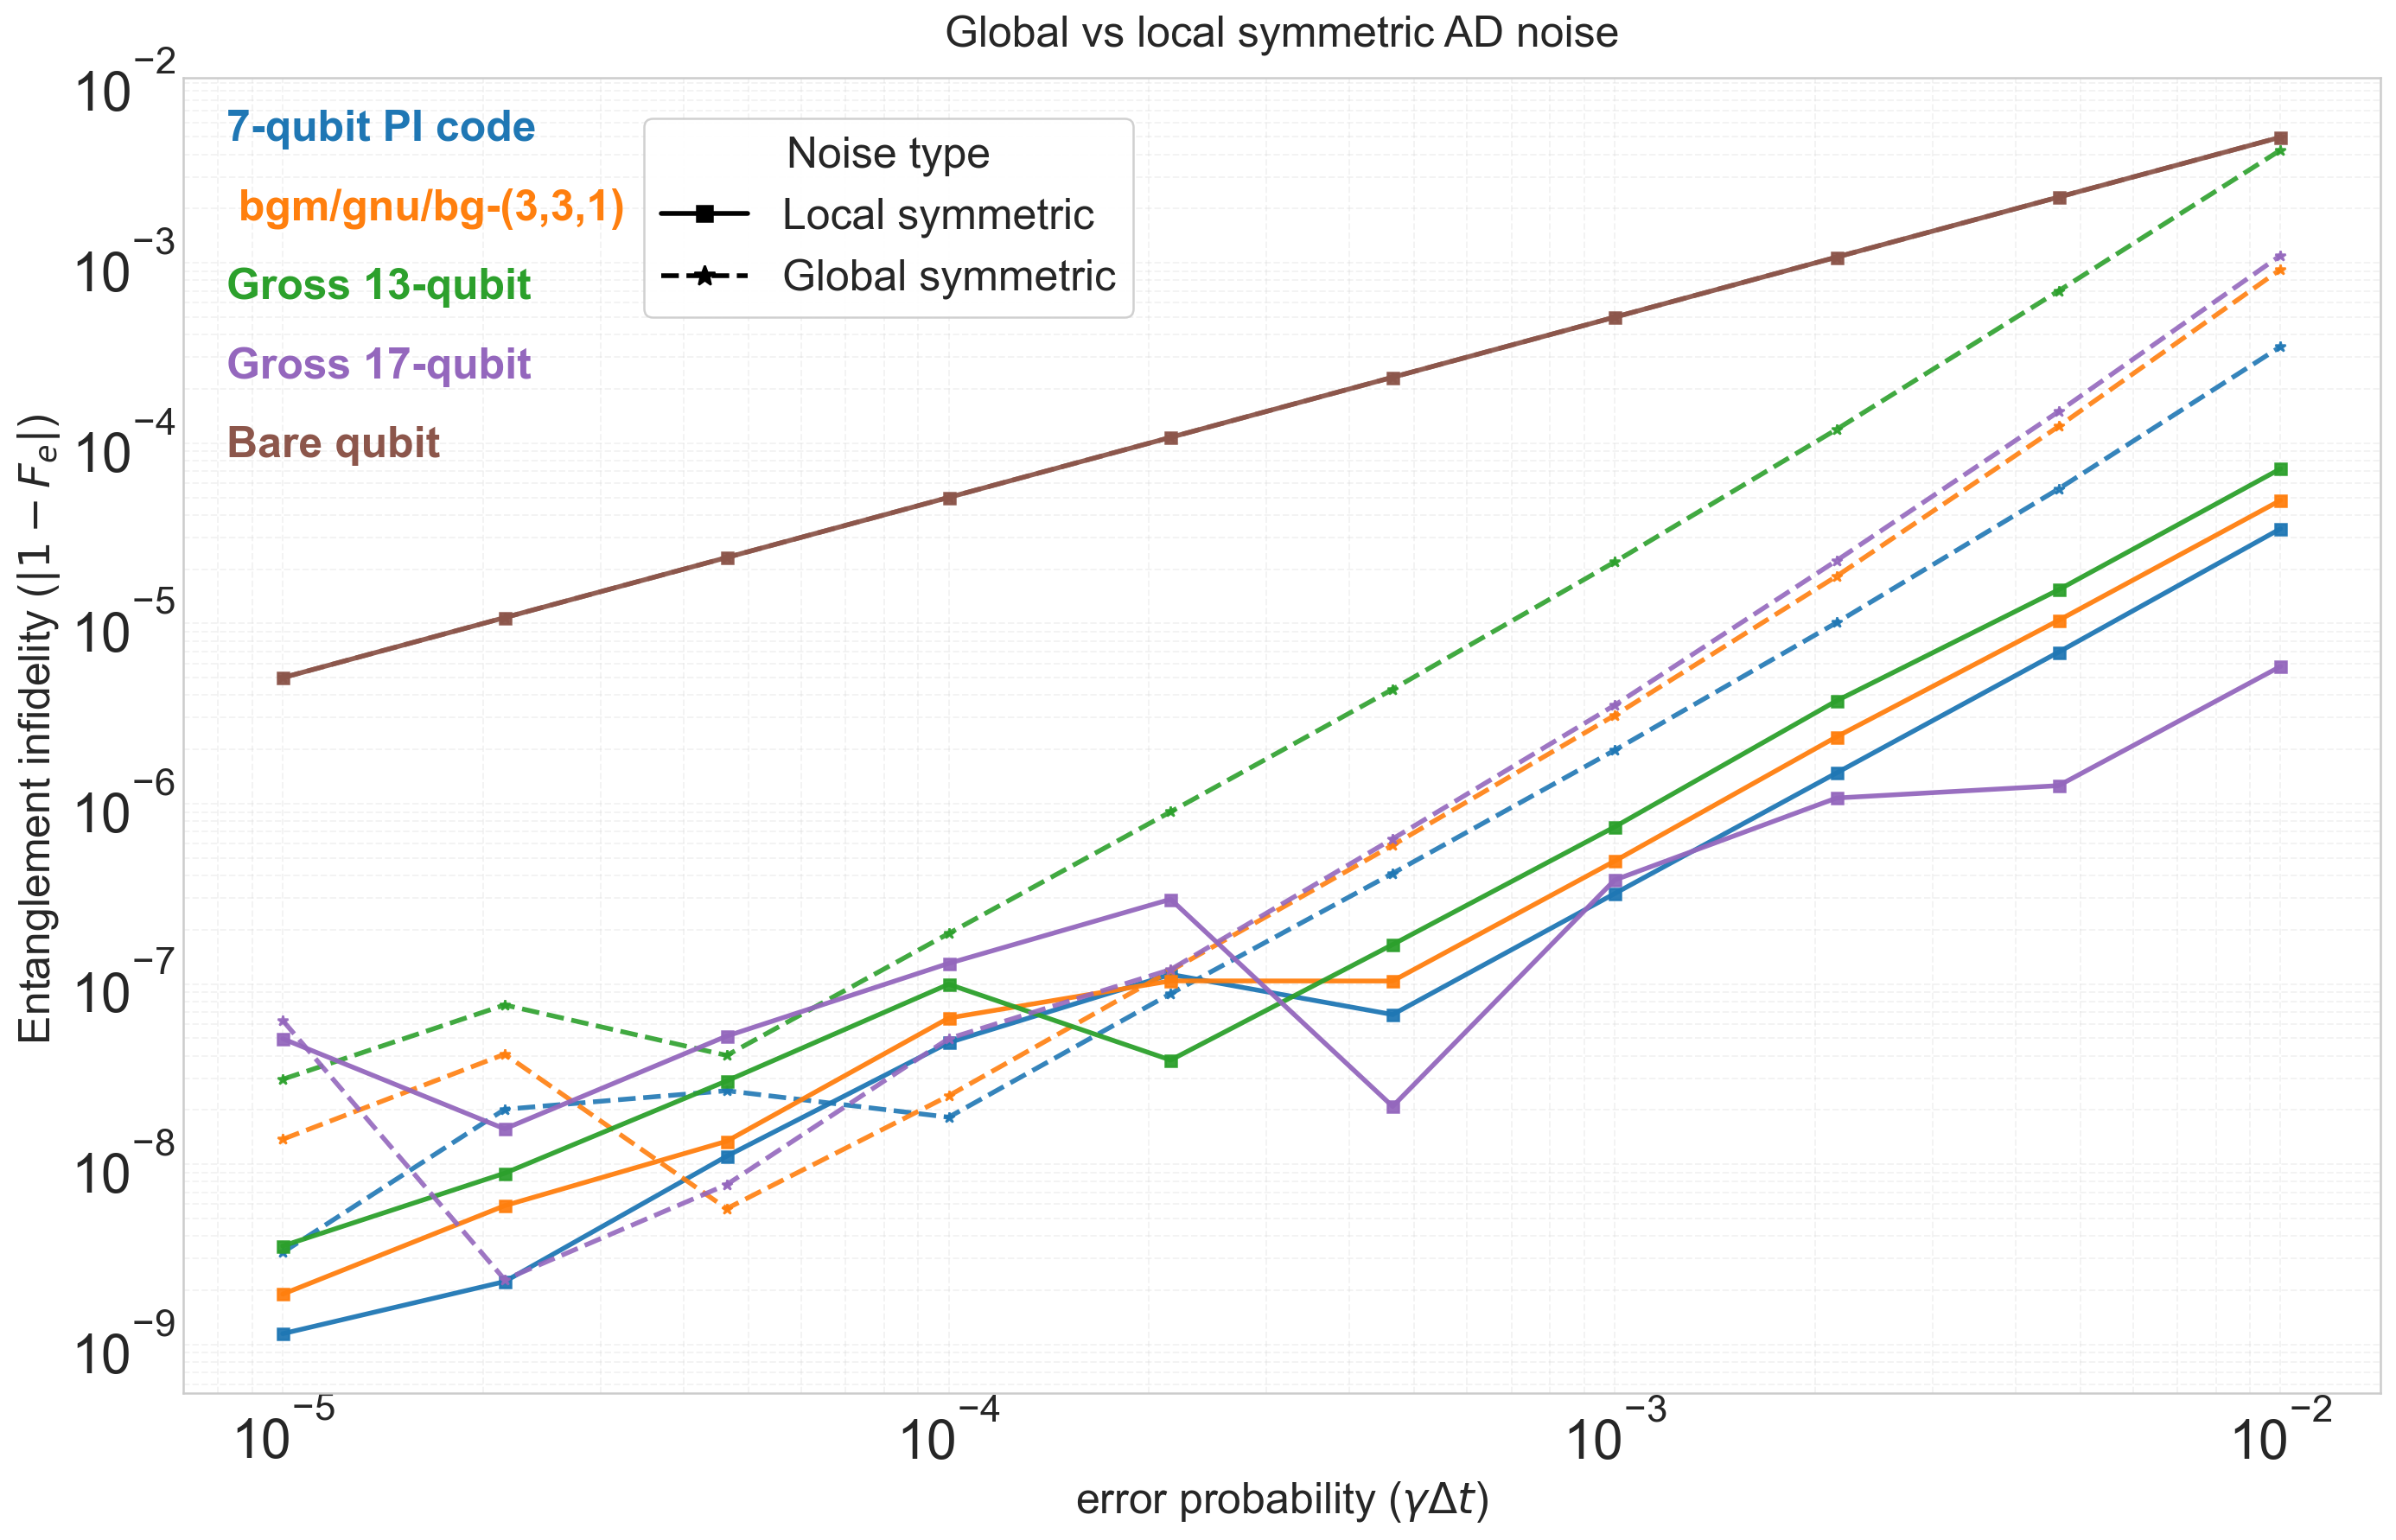

In [29]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use("seaborn-v0_8-whitegrid")

# Allow this cell to run standalone, even if Cell 2 has not been run yet.
if "df_local" not in globals() or "df_global" not in globals():
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "README.md").exists():
            repo_root = candidate
            break
    if repo_root is None:
        repo_root = cwd

    data_dir = repo_root / "datas"
    local_csv = data_dir / "local_amp_damp_results.csv"
    global_csv = data_dir / "global_amp_damp_results.csv"

    if not local_csv.exists():
        raise FileNotFoundError(f"Missing local CSV: {local_csv}")
    if not global_csv.exists():
        raise FileNotFoundError(f"Missing global CSV: {global_csv}")

    df_local = pd.read_csv(local_csv)
    df_global = pd.read_csv(global_csv)

required_col = "gamma_dt"
code_specs = [
    ("seven", "7-qubit PI code"),
    ("bgm", " bgm/gnu/bg-(3,3,1)"),
    ("gross13", "Gross 13-qubit"),
    ("gross17", "Gross 17-qubit"),
    ("bare", "Bare qubit"),
]

def prepare_case(df, case_name):
    if required_col not in df.columns:
        raise ValueError(f"{case_name} CSV is missing required column '{required_col}'")

    out = df.copy()
    for prefix, _ in code_specs:
        no_col = f"{prefix}_no_recovery"
        opt_col = f"{prefix}_optimal"
        if no_col not in out.columns or opt_col not in out.columns:
            raise ValueError(f"{case_name} CSV is missing expected columns for '{prefix}'")

        out[f"{prefix}_best"] = out[[no_col, opt_col]].min(axis=1)

    return out

df_local = prepare_case(df_local, "local")
df_global = prepare_case(df_global, "global")

fig, ax = plt.subplots(figsize=(15.5, 10.0), dpi=180)

palette = {
    "seven": "#1f77b4",
    "bgm": "#ff7f0e",
    "gross13": "#2ca02c",
    "gross17": "#9467bd",
    "bare": "#8c564b",
}
label_fontsize = 20.0
noise_styles = {
    "local": {"marker": "s", "linestyle": "-", "alpha": 0.95},
    "global": {"marker": "*", "linestyle": "--", "alpha": 0.9},
}

for prefix, title in code_specs:
    local_vals = df_local[["gamma_dt", f"{prefix}_best"]].dropna()
    global_vals = df_global[["gamma_dt", f"{prefix}_best"]].dropna()

    ax.loglog(
        local_vals["gamma_dt"],
        local_vals[f"{prefix}_best"],
        color=palette[prefix],
        marker=noise_styles["local"]["marker"],
        linestyle=noise_styles["local"]["linestyle"],
        ms=5.2,
        lw=2.2,
        alpha=noise_styles["local"]["alpha"],
        label=f"{title} - local",
    )
    ax.loglog(
        global_vals["gamma_dt"],
        global_vals[f"{prefix}_best"],
        color=palette[prefix],
        marker=noise_styles["global"]["marker"],
        linestyle=noise_styles["global"]["linestyle"],
        ms=5.2,
        lw=2.2,
        alpha=noise_styles["global"]["alpha"],
        label=f"{title} - global",
    )

ax.set_title("Global vs local symmetric AD noise", fontsize=20, pad=14)
ax.grid(True, which="both", ls="--", alpha=0.22)
ax.set_axisbelow(True)

code_label_positions = [0.96, 0.90, 0.84, 0.78, 0.72]
for (prefix, title), y_pos in zip(code_specs, code_label_positions):
    ax.text(
        0.02,
        y_pos,
        title,
        transform=ax.transAxes,
        color=palette[prefix],
        fontsize=label_fontsize,
        fontweight="semibold",
        ha="left",
        va="center",
    )

noise_handles = [
    Line2D([0], [0], color="black", marker="s", linestyle="-", lw=2.2, ms=7, label="Local symmetric"),
    Line2D([0], [0], color="black", marker="*", linestyle="--", lw=2.2, ms=10, label="Global symmetric"),
]
ax.legend(handles=noise_handles, loc="upper left", bbox_to_anchor=(0.20, 0.985), frameon=True, framealpha=0.92, title="Noise type", fontsize=label_fontsize, title_fontsize=label_fontsize)

ax.set_xlabel(r"error probability ($ \gamma \Delta t$)", fontsize=20)
ax.set_ylabel(r" Entanglement infidelity ($|1 - F_e|$)", fontsize=20)
ax.tick_params(axis="both", which="major", labelsize=25)
fig.tight_layout()
plt.show()